# TECHMIND - Organizacion Inteligente del Conocimiento Tecnico
## Hackathon ONE (Oracle Next Education + Alura + NoCountry) - Grupo G9
### Rol: Equipo de Ciencia de Datos


# **1. Preparación del entorno de desarrollo**

---
## Instalar librerias necesarias


In [19]:
# Instalar librerias que no vienen por defecto en Colab
!pip install joblib skl2onnx onnxruntime -q

print("Librerias instaladas correctamente.")

Librerias instaladas correctamente.


---
## Importar las librerias



In [20]:
import os
import re
import joblib
import pandas as pd
import numpy as np
import logging
import json
from pathlib import Path
import shutil
from google.colab import files

# Librerias para hacer graficos
import matplotlib.pyplot as plt
import seaborn as sns

# Modulos de Scikit-Learn (Machine Learning)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# skl2onnx: convierte modelos de scikit-learn a formato ONNX
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import StringTensorType

# Configuracion de graficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10

# Configuracion de Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

print("COMPLETADO: Librerias cargadas correctamente.")

COMPLETADO: Librerias cargadas correctamente.


---
## Cargar el dataset


**Importante:** En Google Colab, debes subir el archivo manualmente en la carpeta de /content. De no ser así, hacer lo siguiente:
1. Ejecuta la siguiente celda
2. Haz clic en "Choose Files" (Seleccionar archivos)
3. Selecciona el archivo `dataset_hackaton_lenguajes_traducido.csv`

In [21]:
nombre_archivo = 'dataset_hackaton_lenguajes_traducido.csv'

if not os.path.exists(nombre_archivo):
    print(f"Por favor, selecciona el archivo '{nombre_archivo}'")
    archivo_subido = files.upload()
    nombre_archivo = list(archivo_subido.keys())[0]

print(f"\nArchivo listo para procesamiento: {nombre_archivo}")
print(f"Tamaño: {os.path.getsize(nombre_archivo) / (1024 * 1024):.2f} MB")


Archivo listo para procesamiento: dataset_hackaton_lenguajes_traducido.csv
Tamaño: 16.08 MB


# **2. ANÁLISIS EXPLORATORIO DE DATOS (EDA)**

## Exploración de datos

---
### Leer el dataset



In [22]:
ruta_dataset = nombre_archivo

try:
    df = pd.read_csv(ruta_dataset, encoding='utf-8', on_bad_lines='skip')
    print("Archivo leído exitosamente con codificación UTF-8.")
except UnicodeDecodeError:
    df = pd.read_csv(ruta_dataset, encoding='latin-1', on_bad_lines='skip')
    print("Archivo leído exitosamente con codificación latin-1.")

print(f"\nTotal de registros cargados: {len(df)}")
print(f"Total de columnas: {len(df.columns)}")

Archivo leído exitosamente con codificación latin-1.

Total de registros cargados: 5524
Total de columnas: 10


### Inspección de los datos



In [23]:
print("=== INFORMACIÓN DEL DATASET ===")
print(f"Dimensiones iniciales: {df.shape[0]} filas, {df.shape[1]} columnas\n")

# Quedarnos solo con las columnas en español de interés
cols_espanol = ['id', 'titulo', 'subtitulo', 'descripcion', 'categoria', 'lenguaje']
df = df[[c for c in cols_espanol if c in df.columns]].copy()

# Verificar duplicados exactos
duplicados = df.duplicated().sum()
print(f"Filas completamente duplicadas: {duplicados}")
if duplicados > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("-> Duplicados eliminados.")

df.info()

=== INFORMACIÓN DEL DATASET ===
Dimensiones iniciales: 5524 filas, 10 columnas

Filas completamente duplicadas: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5524 entries, 0 to 5523
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           5524 non-null   object
 1   titulo       5522 non-null   object
 2   subtitulo    2966 non-null   object
 3   descripcion  5522 non-null   object
 4   categoria    1142 non-null   object
 5   lenguaje     1142 non-null   object
dtypes: object(6)
memory usage: 259.1+ KB


## Limpieza y preparación de datos

In [24]:
# ==============================================================================
# TRATAMIENTO DE NULOS Y NORMALIZACIÓN DE TEXTO
# ==============================================================================

# 1. Diagnóstico de nulos
print("=== RESUMEN DE VALORES NULOS ===")
display(df.isnull().sum().to_frame(name='Total Nulos'))

# 2. Imputación de vacíos en texto
cols_texto = ['titulo', 'subtitulo', 'descripcion']
for col in cols_texto:
    if col in df.columns:
        df[col] = df[col].fillna('')

# 3. Eliminar filas sin etiqueta objetivo
df = df.dropna(subset=['categoria']).copy().reset_index(drop=True)

# 4. Creación y Normalización del texto consolidado
df['texto_completo'] = (df['titulo'] + " " + df['subtitulo'] + " " + df['descripcion']).str.strip()

def normalizar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'http\S+|www\S+|https\S+', '', texto)  # Eliminar URLs
    texto = re.sub(r'[^\w\s\u00C0-\u00FF]', ' ', texto)     # Conservar letras y tildes
    texto = re.sub(r'\s+', ' ', texto).strip()             # Espacios extra
    return texto

df['texto_limpio'] = df['texto_completo'].apply(normalizar_texto)

print(f"\nProcesamiento completado. Registros listos para entrenamientos: {len(df)}")

=== RESUMEN DE VALORES NULOS ===


,Total Nulos
id,0
titulo,2
subtitulo,2558
descripcion,2
categoria,4382
lenguaje,4382



Procesamiento completado. Registros listos para entrenamientos: 1142


In [25]:
# --- Mostrar estadisticas basicas de los textos ---
print("ESTADISTICAS BASICAS DE LOS TEXTOS:")

longitud_titulos = df['titulo'].fillna('').astype(str).apply(len)
longitud_descripciones = df['descripcion'].fillna('').astype(str).apply(len)

print(f"   Titulos:")
print(f"      - Longitud promedio: {longitud_titulos.mean():.0f} caracteres")
print(f"      - Titulo mas corto:  {longitud_titulos.min()} caracteres")
print(f"      - Titulo mas largo:  {longitud_titulos.max()} caracteres")
print(f"   Descripciones:")
print(f"      - Longitud promedio: {longitud_descripciones.mean():.0f} caracteres")
print(f"      - Descripcion mas corta:  {longitud_descripciones.min()} caracteres")
print(f"      - Descripcion mas larga:  {longitud_descripciones.max()} caracteres")


ESTADISTICAS BASICAS DE LOS TEXTOS:
   Titulos:
      - Longitud promedio: 42 caracteres
      - Titulo mas corto:  3 caracteres
      - Titulo mas largo:  244 caracteres
   Descripciones:
      - Longitud promedio: 1394 caracteres
      - Descripcion mas corta:  8 caracteres
      - Descripcion mas larga:  3424 caracteres


/tmp/ipykernel_2412/213983069.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_2412/213983069.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


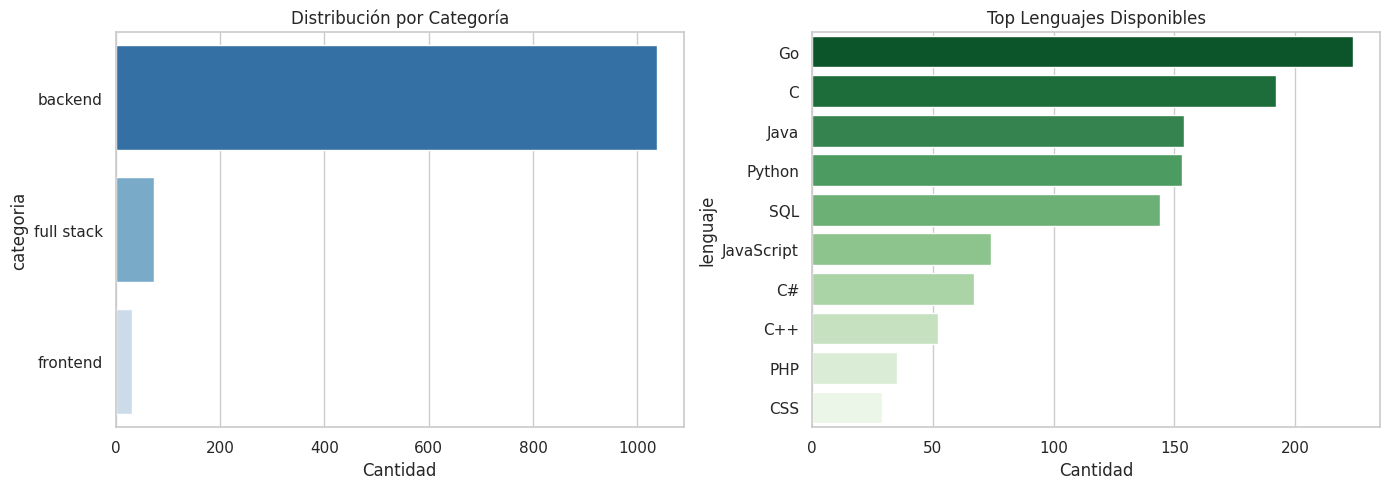


Conteo exacto por categoría:
categoria
backend       1037
full stack      74
frontend        31
Name: count, dtype: int64


In [26]:
# ==============================================================================
# CATEGORÍAS Y LENGUAJES DISPONIBLES
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GRÁFICO 1: Categorías
sns.countplot(
    data=df,
    y='categoria',
    order=df['categoria'].value_counts().index,
    ax=axes[0],
    palette='Blues_r'
)
axes[0].set_title('Distribución por Categoría')
axes[0].set_xlabel('Cantidad')

# GRÁFICO 2: Lenguajes (si la columna existe y no está vacía)
if 'lenguaje' in df.columns and df['lenguaje'].notna().sum() > 0:
    sns.countplot(
        data=df,
        y='lenguaje',
        order=df['lenguaje'].value_counts().iloc[:10].index,
        ax=axes[1],
        palette='Greens_r'
    )
    axes[1].set_title('Top Lenguajes Disponibles')
    axes[1].set_xlabel('Cantidad')

plt.tight_layout()
plt.show()

print("\nConteo exacto por categoría:")
print(df['categoria'].value_counts())

## Visualización y análisis de datos



GENERANDO GRAFICOS EXPLORATORIOS...

Generando gráfico: Top 10 Categorías...


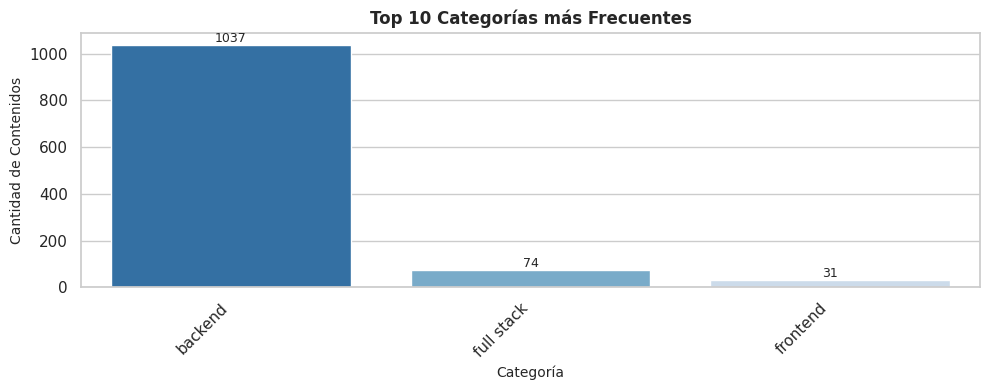

Gráfico de categorías generado.


In [27]:
print("GENERANDO GRAFICOS EXPLORATORIOS...")

# Listado de valores basura a ignorar en las gráficas
valores_invalidos = ['', 'nan', 'none', '#valor!', 'null', 'undefined']

# 1. Obtener series limpias directamente del DataFrame 'df'
cat_series = df['categoria'].dropna().astype(str).str.strip().str.lower()
len_series = df['lenguaje'].dropna().astype(str).str.strip().str.lower()

cat_para_grafico = cat_series[~cat_series.isin(valores_invalidos)]
len_para_grafico = len_series[~len_series.isin(valores_invalidos)]

# GRAFICO 3: Top 10 Categorias
print("\nGenerando gráfico: Top 10 Categorías...")
top_categorias = cat_para_grafico.value_counts().head(10)

plt.figure(figsize=(10, 4))
grafico_cat = sns.barplot(
    x=top_categorias.index,
    y=top_categorias.values,
    hue=top_categorias.index,
    palette="Blues_r",
    legend=False
)
plt.title("Top 10 Categorías más Frecuentes", fontsize=12, fontweight='bold')
plt.xlabel("Categoría", fontsize=10)
plt.ylabel("Cantidad de Contenidos", fontsize=10)
plt.xticks(rotation=45, ha='right')

for barra in grafico_cat.patches:
    if barra.get_height() > 0:
        grafico_cat.annotate(
            f'{int(barra.get_height())}',
            (barra.get_x() + barra.get_width() / 2., barra.get_height()),
            ha='center', va='bottom', fontsize=9
        )

plt.tight_layout()
plt.show()
print("Gráfico de categorías generado.")

Generando grafico: Top 10 Lenguajes de Programacion...


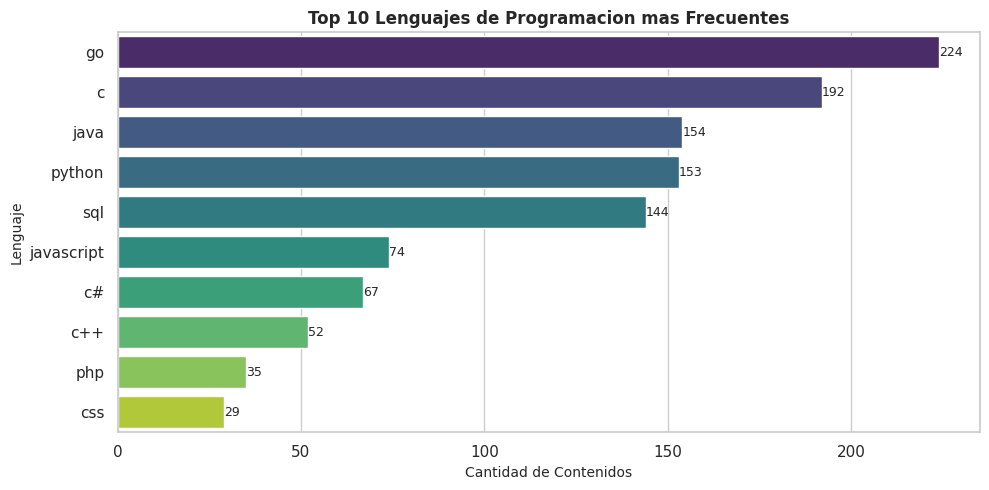

Grafico de lenguajes generado.


In [28]:
# GRÁFICO 4: Top 10 Lenguajes de Programación
print("Generando grafico: Top 10 Lenguajes de Programacion...")
top_lenguajes = len_para_grafico.value_counts().head(10)

plt.figure(figsize=(10, 5))
grafico_len = sns.barplot(
    y=top_lenguajes.index,
    x=top_lenguajes.values,
    hue=top_lenguajes.index,
    palette="viridis",
    legend=False
)
plt.title("Top 10 Lenguajes de Programacion mas Frecuentes", fontsize=12, fontweight='bold')
plt.xlabel("Cantidad de Contenidos", fontsize=10)
plt.ylabel("Lenguaje", fontsize=10)

for barra in grafico_len.patches:
    if barra.get_width() > 0:
        grafico_len.annotate(
            f'{int(barra.get_width())}',
            (barra.get_width(), barra.get_y() + barra.get_height() / 2.),
            ha='left', va='center', fontsize=9
        )
plt.tight_layout()
plt.show()
print("Grafico de lenguajes generado.")

Generando grafico: Distribucion de palabras en los textos...


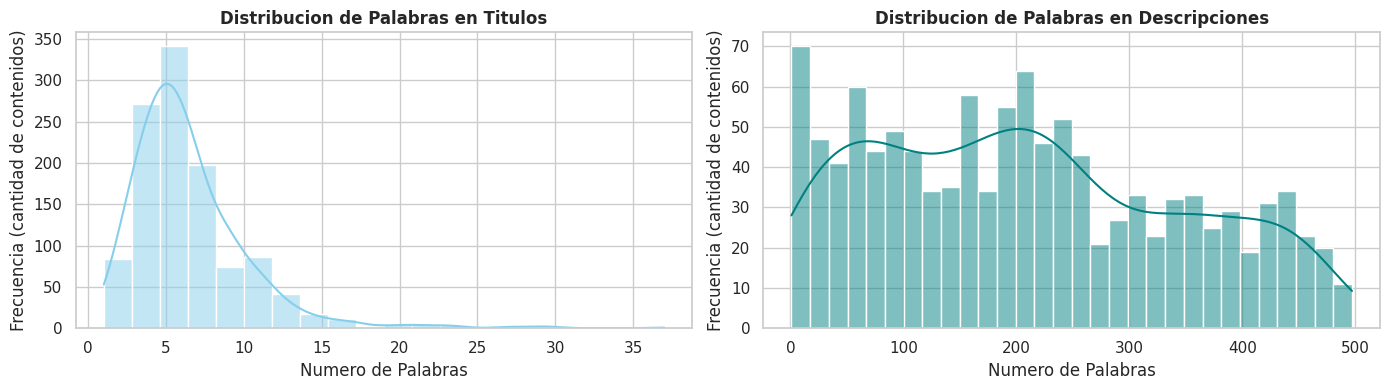

Grafico de distribucion de palabras generado.


In [29]:
# GRÁFICOS 5 Y 6: Distribucion de palabras en titulos y descripciones
print("Generando grafico: Distribucion de palabras en los textos...")

df_temp = df.copy()
df_temp['palabras_titulo'] = df_temp['titulo'].fillna('').astype(str).apply(lambda x: len(x.split()))
df_temp['palabras_descripcion'] = df_temp['descripcion'].fillna('').astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df_temp['palabras_titulo'], kde=True, ax=axes[0], color='skyblue', bins=20)
axes[0].set_title("Distribucion de Palabras en Titulos", fontweight='bold')
axes[0].set_xlabel("Numero de Palabras")
axes[0].set_ylabel("Frecuencia (cantidad de contenidos)")

sns.histplot(
    df_temp['palabras_descripcion'][df_temp['palabras_descripcion'] < 500],
    kde=True, ax=axes[1], color='teal', bins=30
)
axes[1].set_title("Distribucion de Palabras en Descripciones", fontweight='bold')
axes[1].set_xlabel("Numero de Palabras")
axes[1].set_ylabel("Frecuencia (cantidad de contenidos)")

plt.tight_layout()
plt.show()
print("Grafico de distribucion de palabras generado.")

# **3. PREPARACIÓN DE DATOS PARA EL MODELADO**

## Limpieza profunda de los textos para el modelado

Esta funcion prepara los textos para que el modelo pueda entenderlos. Convierte todo a minusculas, elimina signos de puntuacion, numeros y espacios de mas.

Ademas, definimos una lista de **Stop Words en espanol** (palabras muy comunes como "el", "la", "que", "de") que no aportan significado al modelo. Al eliminarlas, el modelo se enfoca en las palabras realmente importantes.

In [30]:
# Lista de Stop Words en espanol (palabras muy comunes sin valor semantico)
# El modelo ignorara estas palabras para enfocarse en las realmente importantes
STOP_WORDS_ESPANOL = [
    'de', 'la', 'que', 'el', 'en', 'y', 'a', 'los', 'del', 'se', 'las', 'por',
    'un', 'para', 'con', 'no', 'una', 'su', 'al', 'lo', 'como', 'mas', 'pero',
    'sus', 'le', 'ya', 'o', 'este', 'si', 'porque', 'esta', 'entre', 'cuando',
    'muy', 'sin', 'sobre', 'tambien', 'me', 'hasta', 'hay', 'donde', 'quien',
    'todo', 'solo', 'que', 'ella', 'era', 'son', 'dos', 'tiene', 'han',
    'puede', 'ser', 'fue', 'tan', 'como', 'cada', 'ese', 'si', 'desde', 'nos',
    'ni', 'caso', 'sino', 'este', 'tener', 'hacer', 'otros', 'otra', 'poco',
    'mismo', 'mismos', 'misma', 'mismas', 'gran', 'esta', 'esto', 'ante',
    'ellos', 'ellas', 'ello', 'unas', 'unos', 'voy', 'vas', 'va', 'vamos',
    'van', 'vaya', 'vayas', 'vayamos', 'vayan', 'he', 'has', 'ha', 'hemos',
    'han', 'haya', 'hayas', 'hayamos', 'hayan', 'estoy', 'estas', 'esta',
    'estamos', 'estan', 'este', 'estes', 'estemos', 'esten', 'sere', 'seras',
    'sera', 'seremos', 'seran', 'sea', 'seas', 'seamos', 'sean', 'habia',
    'habias', 'habia', 'habiamos', 'habian', 'habra', 'habras', 'habra',
    'habremos', 'habran', 'hubo', 'hubiste', 'hubo', 'hubimos', 'hubieron',
    'hubiera', 'hubieras', 'hubiera', 'hubieramos', 'hubieran', 'hubiese',
    'hubieses', 'hubiese', 'hubiesemos', 'hubiesen', 'tuviera', 'tuvieras',
    'tuviera', 'tuvieramos', 'tuvieran', 'tuviese', 'tuvieses', 'tuviese',
    'tuviesemos', 'tuviesen', 'tenga', 'tengas', 'tenga', 'tengamos', 'tengan',
    'tendre', 'tendras', 'tendra', 'tendremos', 'tendran', 'tengo', 'tienes',
    'tiene', 'tenemos', 'tienen', 'tuve', 'tuviste', 'tuvo', 'tuvimos',
    'tuvieron', 'hago', 'haces', 'hace', 'hacemos', 'hacen', 'hice', 'hiciste',
    'hizo', 'hicimos', 'hicieron', 'haria', 'harias', 'haria', 'hariamos',
    'harian', 'hagan', 'hagas', 'haga', 'hagamos', 'hagan'
]

print(f"Stop Words en espanol cargadas: {len(STOP_WORDS_ESPANOL)} palabras.")


def limpiar_texto(texto):

    if not isinstance(texto, str):
        return ""

    texto = texto.lower()
    texto = re.sub(r'http\S+|www\S+|https\S+', '', texto)  # Eliminar URLs/enlaces
    texto = re.sub(r'[^\w\s\u00C0-\u00FF]', ' ', texto)     # Conservar letras, números, tildes y ñ
    texto = re.sub(r'\s+', ' ', texto).strip()             # Eliminar espacios múltiples
    return texto

# Verificación directa en la celda
ejemplo_prueba = "¡Texto de PRUEBA para NLP! Visita https://example.com"
print("Original:", ejemplo_prueba)
print("Limpio:  ", limpiar_texto(ejemplo_prueba))

Stop Words en espanol cargadas: 194 palabras.
Original: ¡Texto de PRUEBA para NLP! Visita https://example.com
Limpio:   texto de prueba para nlp visita


## Preprocesamiento de textos (NLP)

El preprocesamiento es preparar los textos para que el modelo pueda entenderlos.

In [31]:
# ==============================================================================
# PREPROCESAMIENTO Y PREPARACIÓN DE TEXTOS (NLP)
# ==============================================================================

print("=== PREPROCESAMIENTO DE TEXTOS ===")

# 1. Combinar las columnas en español
print("\nCombinando columnas de texto...")
columnas_texto = ['titulo', 'subtitulo', 'descripcion']

for col in columnas_texto:
    df[col] = df[col].fillna('').astype(str)

df['texto_completo'] = (
    df['titulo'] + " " +
    df['subtitulo'] + " " +
    df['descripcion']
).str.strip()

# 2. Aplicar la limpieza de texto
print("Limpiando y normalizando textos...")
df['texto_limpio'] = df['texto_completo'].apply(limpiar_texto)

# 3. Eliminar textos muy cortos
print("Eliminando textos muy cortos (<= 10 caracteres)...")
registros_antes = len(df)
df = df[df['texto_limpio'].str.len() > 10].copy().reset_index(drop=True)
registros_despues = len(df)

print(f"\nProceso completado.")
print(f"Se eliminaron {registros_antes - registros_despues} registros por ser demasiado cortos.")
print(f"Total de registros listos para el modelo: {registros_despues}")

=== PREPROCESAMIENTO DE TEXTOS ===

Combinando columnas de texto...
Limpiando y normalizando textos...
Eliminando textos muy cortos (<= 10 caracteres)...

Proceso completado.
Se eliminaron 0 registros por ser demasiado cortos.
Total de registros listos para el modelo: 1142


## Procesamiento de datos para el modelado

Ahora separamos los datos en:
- **X**: Los textos de entrada (lo que el modelo va a leer)
- **y_categoria**: La categoria a predecir (backend, frontend, full stack)
- **y_lenguaje**: El lenguaje a predecir (Python, Java, etc.)

Luego dividimos en **entrenamiento (80%)** y **prueba (20%)**.

In [32]:
# Configuración del Logger
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger("DataPrep")

def preparar_y_dividir_datos(
    df_input: pd.DataFrame,
    col_texto: str = 'texto_limpio',
    min_ejemplos: int = 2,
    test_size: float = 0.2,
    random_state: int = 42
):
    """
    Filtra datos no representativos, codifica etiquetas objetivas
    y realiza una división Train/Test estratificada y segura.
    """
    logger.info("=== INICIANDO PREPARACIÓN Y SPLIT DE DATOS ===")

    # 1. Preservar inmutabilidad: Trabajar sobre copia filtrada sin sobrescribir el original
    categorias_validas = df_input['categoria'].value_counts()
    categorias_validas = categorias_validas[categorias_validas >= min_ejemplos].index

    lenguajes_validos = df_input['lenguaje'].value_counts()
    lenguajes_validos = lenguajes_validos[lenguajes_validos >= min_ejemplos].index

    df_modelo = df_input[
        df_input['categoria'].isin(categorias_validas) &
        df_input['lenguaje'].isin(lenguajes_validos)
    ].copy()

    logger.info(f"Registros originales: {len(df_input)} | Registros filtrados para modelado: {len(df_modelo)}")

    # 2. Definir Features (X) y Etiquetas (y)
    X = df_modelo[col_texto]

    # 3. Codificación de Etiquetas (Label Encoding)
    le_categoria = LabelEncoder()
    le_lenguaje = LabelEncoder()

    y_cat_encoded = le_categoria.fit_transform(df_modelo['categoria'])
    y_len_encoded = le_lenguaje.fit_transform(df_modelo['lenguaje'])

    logger.info(f"Clases 'categoria' ({len(le_categoria.classes_)}): {list(le_categoria.classes_)}")
    logger.info(f"Clases 'lenguaje' ({len(le_lenguaje.classes_)}): {list(le_lenguaje.classes_)}")

    # 4. Construir Estrato Combinado para Estratificación Robusta
    estrato_combinado = df_modelo['categoria'].astype(str) + "_" + df_modelo['lenguaje'].astype(str)
    conteo_estratos = estrato_combinado.value_counts()

    # Si todos los estratos combinados tienen al menos min_ejemplos, estratificamos por la combinación
    if (conteo_estratos >= min_ejemplos).all():
        estrato_final = estrato_combinado
        logger.info("Estrategia de Estratificación: Combinada (Categoría + Lenguaje).")
    else:
        estrato_final = y_cat_encoded
        logger.info("Estrategia de Estratificación: Fallback a Categoria (combinación con registros insuficientes).")

    # 5. División Train / Test
    (
        X_train, X_test,
        y_cat_train, y_cat_test,
        y_len_train, y_len_test
    ) = train_test_split(
        X,
        y_cat_encoded,
        y_len_encoded,
        test_size=test_size,
        random_state=random_state,
        stratify=estrato_final
    )

    logger.info(f"División completada -> Train: {len(X_train)} ejemplos | Test: {len(X_test)} ejemplos")
    logger.info("==================================================")

    return {
        "df_modelo": df_modelo,
        "X_train": X_train,
        "X_test": X_test,
        "y_cat_train": y_cat_train,
        "y_cat_test": y_cat_test,
        "y_len_train": y_len_train,
        "y_len_test": y_len_test,
        "le_categoria": le_categoria,
        "le_lenguaje": le_lenguaje
    }


# --- EJECUCIÓN EN EL CUADERNO ---
# Asumiendo que 'df' es tu DataFrame original cargado
datos_preparados = preparar_y_dividir_datos(df)

# Desempaquetado explícito para mantener compatibilidad total con tus pasos posteriores (10 y 12)
df_modelo = datos_preparados["df_modelo"]
X_train, X_test = datos_preparados["X_train"], datos_preparados["X_test"]
y_cat_train, y_cat_test = datos_preparados["y_cat_train"], datos_preparados["y_cat_test"]
y_len_train, y_len_test = datos_preparados["y_len_train"], datos_preparados["y_len_test"]
le_categoria = datos_preparados["le_categoria"]
le_lenguaje = datos_preparados["le_lenguaje"]

## Verificación de limpieza del dataset para el modelado

Ahora que el dataset esta limpio y filtrado, generamos graficos para ver como quedo la distribucion final de los datos antes de entrenar los modelos.

Generando gráfico: Distribución final de CATEGORÍAS...


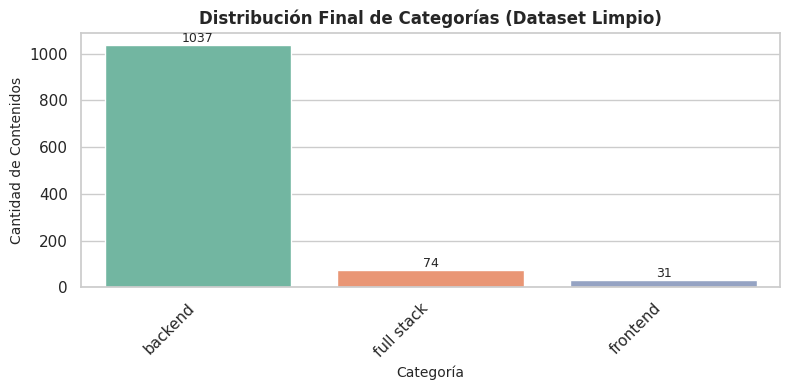

Gráfico de distribución final de categorías generado.


In [33]:
print("Generando gráfico: Distribución final de CATEGORÍAS...")

# 1. Unir los arreglos de numpy de Train y Test
y_cat_completo_encoded = np.concatenate([y_cat_train, y_cat_test])

# 2. Decodificar los IDs numéricos a sus nombres de texto originales
y_cat_nombres = le_categoria.inverse_transform(y_cat_completo_encoded)

# 3. Contar frecuencias
conteo_cat_final = pd.Series(y_cat_nombres).value_counts()

# 4. Graficar
plt.figure(figsize=(8, 4))
grafico_cat_final = sns.barplot(
    x=conteo_cat_final.index,
    y=conteo_cat_final.values,
    hue=conteo_cat_final.index,
    palette="Set2",
    legend=False
)


# GRÁFICO 7. Distribución de categorías
plt.title("Distribución Final de Categorías (Dataset Limpio)", fontsize=12, fontweight='bold')
plt.xlabel("Categoría", fontsize=10)
plt.ylabel("Cantidad de Contenidos", fontsize=10)
plt.xticks(rotation=45, ha='right')

for barra in grafico_cat_final.patches:
    if barra.get_height() > 0:
        grafico_cat_final.annotate(
            f'{int(barra.get_height())}',
            (barra.get_x() + barra.get_width() / 2., barra.get_height()),
            ha='center', va='bottom', fontsize=9
        )

plt.tight_layout()
plt.show()
print("Gráfico de distribución final de categorías generado.")

Generando grafico: Top 10 LENGUAJES (post-limpieza)...


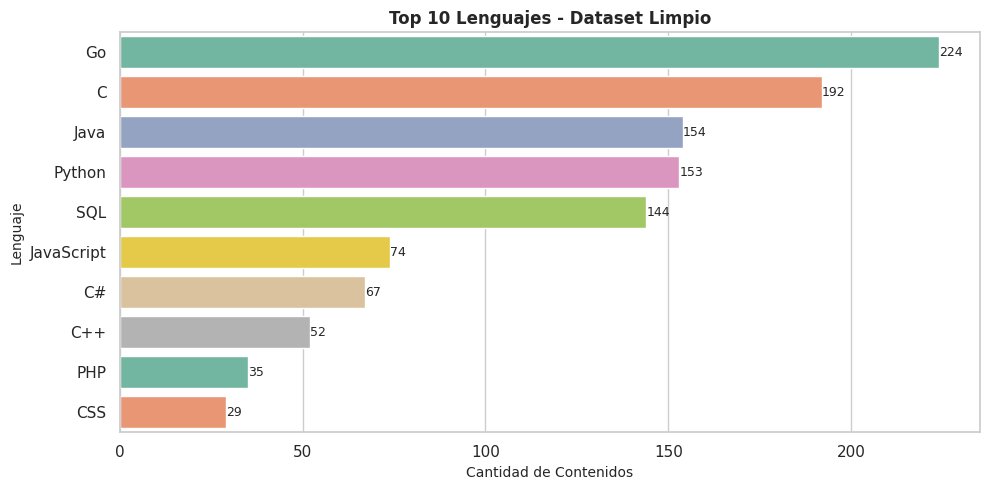

Grafico de lenguajes post-limpieza generado.


In [34]:
# GRÁFICO 8: Top 10 lenguajes post-limpieza
print("Generando grafico: Top 10 LENGUAJES (post-limpieza)...")

# 1. Recuperar los datos del dataset limpio a partir de los arreglos de Train y Test
y_len_completo_encoded = np.concatenate([y_len_train, y_len_test])
y_len_nombres = le_lenguaje.inverse_transform(y_len_completo_encoded)

# 2. Obtener el Top 10
top_leng_final = pd.Series(y_len_nombres).value_counts().head(10)

# 3. Graficar en formato horizontal
plt.figure(figsize=(10, 5))
grafico_len_final = sns.barplot(
    y=top_leng_final.index,
    x=top_leng_final.values,
    hue=top_leng_final.index,
    palette="Set2",
    legend=False
)

plt.title("Top 10 Lenguajes - Dataset Limpio", fontsize=12, fontweight='bold')
plt.xlabel("Cantidad de Contenidos", fontsize=10)
plt.ylabel("Lenguaje", fontsize=10)

# Anotación para barras horizontales (usando get_width)
for barra in grafico_len_final.patches:
    if barra.get_width() > 0:
        grafico_len_final.annotate(
            f'{int(barra.get_width())}',
            (barra.get_width(), barra.get_y() + barra.get_height() / 2.),
            ha='left', va='center', fontsize=9
        )

plt.tight_layout()
plt.show()
print("Grafico de lenguajes post-limpieza generado.")

In [35]:
# Reconstrucción de los datos concatenados
y_cat_completo = le_categoria.inverse_transform(np.concatenate([y_cat_train, y_cat_test]))
y_len_completo = le_lenguaje.inverse_transform(np.concatenate([y_len_train, y_len_test]))

# Métrica de total de registros limpios
total_registros_limpios = len(y_cat_completo)

# Clases únicas
categorias_unicas = np.unique(y_cat_completo)
num_lenguajes = len(np.unique(y_len_completo))

print("RESUMEN DE LIMPIEZA DE TEXTOS:")
print(f"   - Registros listos tras filtrado: {total_registros_limpios}")
print(f"   - Categorias disponibles ({len(categorias_unicas)}): {list(categorias_unicas)}")
print(f"   - Lenguajes disponibles:           {num_lenguajes}")
print("==================================================")
print("Dataset consolidado y listo para la fase de modelado.")

RESUMEN DE LIMPIEZA DE TEXTOS:
   - Registros listos tras filtrado: 1142
   - Categorias disponibles (3): ['backend', 'frontend', 'full stack']
   - Lenguajes disponibles:           14
Dataset consolidado y listo para la fase de modelado.


# **4. Entrenamiento y evaluación de los modelos de Machine Learning**




## Entrenamiento de modelos
**PASO 1 - TF-IDF**: Convierte palabras a numeros. Cuenta cuantas veces aparece cada palabra, pero le da menos importancia a palabras muy comunes (como "el", "la", "que").

**PASO 2 - LogisticRegression**: El clasificador. Es el "cerebro" que aprende a asociar ciertas palabras con cada categoria.

In [36]:
# 1. Configuración simplificada de logging (se hereda en todo el cuaderno)
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

print("=== ENTRENANDO MODELOS DE MACHINE LEARNING ===")

# --- MODELO 1: Clasificador de Categorías ---
logging.info("Creando Pipeline para clasificación de CATEGORÍAS...")
pipeline_categoria = Pipeline([
    ('vectorizador', TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        stop_words= STOP_WORDS_ESPANOL
    )),
    ('clasificador', LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight='balanced'
    ))
])

=== ENTRENANDO MODELOS DE MACHINE LEARNING ===


In [37]:
# --- MODELO 2: Clasificador de Lenguajes ---
logging.info("Creando Pipeline para clasificación de LENGUAJES...")
pipeline_lenguaje = Pipeline([
    ('vectorizador', TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        stop_words=STOP_WORDS_ESPANOL
    )),
    ('clasificador', LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight='balanced'
    ))
])

In [38]:
# --- ENTRENAMIENTO ---
try:
    logging.info("Entrenando el modelo de CATEGORÍAS...")
    pipeline_categoria.fit(X_train, y_cat_train)
    logging.info(" [OK] Modelo de categorías entrenado exitosamente.")

    logging.info("Entrenando el modelo de LENGUAJES...")
    pipeline_lenguaje.fit(X_train, y_len_train)
    logging.info(" [OK] Modelo de lenguajes entrenado exitosamente.")

    logging.info("=== ENTRENAMIENTO FINALIZADO CON ÉXITO ===")

except Exception as e:
    logging.error(f"Error durante el entrenamiento de los modelos: {e}")
    raise e

## Evaluacion de los modelos

Probamos que tan bien aprendieron los modelos con los datos de PRUEBA (el 20% que separamos al inicio y que NUNCA vieron antes).

In [39]:
print("=== EVALUANDO EL DESEMPENO DE LOS MODELOS ===")

print("\nRealizando predicciones sobre los datos de prueba...")
predicciones_categoria = pipeline_categoria.predict(X_test)
predicciones_lenguaje = pipeline_lenguaje.predict(X_test)
print("Predicciones realizadas.")

# --- METRICA 1: Accuracy (Precision General) ---
print("\nMETRICA PRINCIPAL - ACCURACY (Precision):")

accuracy_cat = accuracy_score(y_cat_test, predicciones_categoria)
accuracy_len = accuracy_score(y_len_test, predicciones_lenguaje)

print(f"\nPrecision en CATEGORIA: {accuracy_cat * 100:.2f}%")
print(f"   (de {len(y_cat_test)} textos de prueba, acerto {int(accuracy_cat * len(y_cat_test))})")
print(f"Precision en LENGUAJE:  {accuracy_len * 100:.2f}%")
print(f"   (de {len(y_len_test)} textos de prueba, acerto {int(accuracy_len * len(y_len_test))})")

=== EVALUANDO EL DESEMPENO DE LOS MODELOS ===

Realizando predicciones sobre los datos de prueba...
Predicciones realizadas.

METRICA PRINCIPAL - ACCURACY (Precision):

Precision en CATEGORIA: 99.13%
   (de 229 textos de prueba, acerto 227)
Precision en LENGUAJE:  89.08%
   (de 229 textos de prueba, acerto 204)


In [40]:
# --- REPORTE CATEGORÍA ---
print("REPORTE DETALLADO - CATEGORÍA:")
print(classification_report(
    y_cat_test,
    predicciones_categoria,
    labels=range(len(le_categoria.classes_)),
    target_names=le_categoria.classes_,
    zero_division=0
))

# --- REPORTE LENGUAJE ---
print("REPORTE DETALLADO - LENGUAJE:")
print(classification_report(
    y_len_test,
    predicciones_lenguaje,
    labels=range(len(le_lenguaje.classes_)),
    target_names=le_lenguaje.classes_,
    zero_division=0
))

REPORTE DETALLADO - CATEGORÍA:
              precision    recall  f1-score   support

     backend       1.00      0.99      1.00       208
    frontend       1.00      1.00      1.00         6
  full stack       0.88      1.00      0.94        15

    accuracy                           0.99       229
   macro avg       0.96      1.00      0.98       229
weighted avg       0.99      0.99      0.99       229

REPORTE DETALLADO - LENGUAJE:
              precision    recall  f1-score   support

           C       0.76      0.87      0.81        39
          C#       1.00      0.54      0.70        13
         C++       0.75      0.90      0.82        10
         CSS       1.00      1.00      1.00         6
          Go       0.88      0.82      0.85        45
        HTML       0.00      0.00      0.00         0
     Haskell       1.00      1.00      1.00         1
        Java       0.94      1.00      0.97        31
  JavaScript       0.94      1.00      0.97        15
      MATLAB     


Generando Matriz de Confusion...


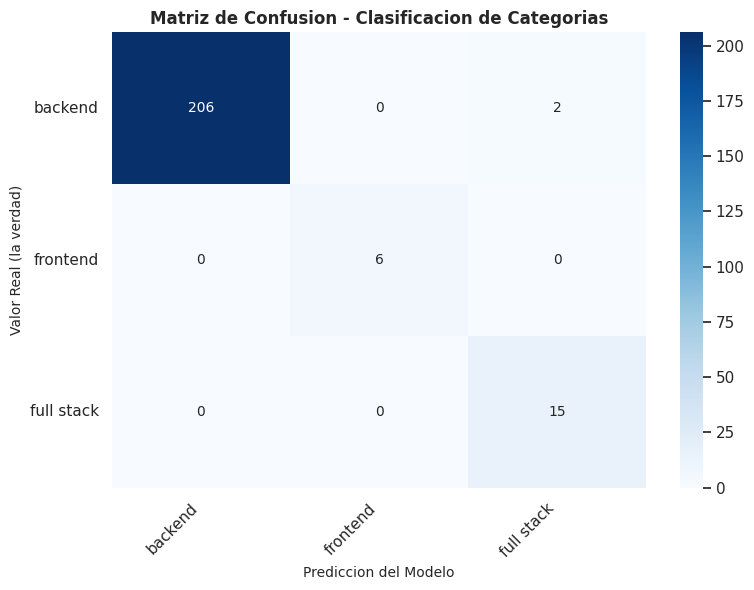

Matriz de confusion generada.


In [41]:
# GRAFICO 9: Matriz de Confusion
# La matriz de confusion es una tabla que muestra:
# - En las filas: la categoria REAL (la verdad)
# - En las columnas: lo que el modelo PREDIJO
# Los numeros en la diagonal (de esquina a esquina) son ACIERTOS.
# Los numeros fuera de la diagonal son ERRORES.

print("\nGenerando Matriz de Confusion...")

plt.figure(figsize=(8, 6))
matriz_confusion = confusion_matrix(y_cat_test, predicciones_categoria)

sns.heatmap(
    matriz_confusion,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le_categoria.classes_,
    yticklabels=le_categoria.classes_
)
plt.title("Matriz de Confusion - Clasificacion de Categorias", fontweight='bold', fontsize=12)
plt.xlabel("Prediccion del Modelo", fontsize=10)
plt.ylabel("Valor Real (la verdad)", fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
print("Matriz de confusion generada.")

In [42]:
# --- Analisis de errores ---
print("\nANALISIS DE ERRORES (CATEGORIAS):")
error_indices = y_cat_test != predicciones_categoria
total_errores = error_indices.sum()

if total_errores > 0:
    errores_df = pd.DataFrame({
        'Texto Limpio': X_test[error_indices].iloc[:3].values,
        'Categoria Real': le_categoria.inverse_transform(y_cat_test[error_indices][:3]),
        'Categoria Predicha': le_categoria.inverse_transform(predicciones_categoria[error_indices][:3])
    })
    print(f"Se encontraron {total_errores} errores en categorias.")
    print("Mostrando los primeros errores como ejemplo:")
    display(errores_df)
else:
    print("¡No se encontraron errores! El modelo acerto todas las predicciones de prueba.")


ANALISIS DE ERRORES (CATEGORIAS):
Se encontraron 2 errores en categorias.
Mostrando los primeros errores como ejemplo:


,Texto Limpio,Categoria Real,Categoria Predicha
0,javascript práctico para desarrolladores de python aprovecha tus conocimientos de python para aprender rápidamente javascript y avanzar en tu carrera como desarrollador web crea aplicaciones web full stack robustas usando dos de los lenguajes de programación más populares del mundo python y javascriptcaracterísticas clavedescubre similitudes y diferencias entre las convenciones de programación de javascript y pythonexplora conceptos web frontend técnicas ui ux y frameworks javascript para mejorar tus habilidades en desarrollo webpon en práctica tus conocimientos de js desarrollando una aplicación web full stack con react y expressbook descripciónel conocimiento de python es una gran base para aprender otros idiomas este libro te ayudará a avanzar en tu carrera como ingeniero de software aprovechando tus habilidades de programación en python para aprender javascript y aplicar sus características únicas no solo para el desarrollo web frontend sino también para agilizar el trabajo en backend empezando por lo básico de javascript cubrirás su sintaxis su uso en el navegador y sus frameworks y librerías desde trabajar con las interacciones de los usuarios e ingestión de datos de apis hasta crear apis con node js este libro te ayudará a empezar a usar javascript mediante ejercicios prácticos fragmentos de código y descripciones detalladas de la implementación y beneficios de javascript para entender el uso de javascript en el backend explorarás node js y descubrirás cómo se comunica con bases de datos a medida que avances te familiarizarás con la creación de tus propias apis restful y conectando el frontend y el backend para obtener un conocimiento holístico de desarrollo full stack al final de este libro de javascript en python tendrás los conocimientos necesarios para escribir aplicaciones web completas de principio a fin también habrás adquirido experiencia práctica trabajando en varios proyectos lo que te ayudará a avanzar en tu carrera como desarrollador javascript lo que aprenderásdescubre las diferencias entre python y javascript tanto a nivel sintáctico como semánticofamiliarizarte con la implementación de javascript tanto en el frontend como en el backendentender la separación de preocupaciones al usar programación en python para el desarrollo en servidorfamiliarizarte con las tareas de desarrollo web frontend incluyendo diseño ui ux validación de formularios animaciones y mucho máscrea interfaces de interacción modernas para tu aplicación web en pythonexplora la web moderna tecnologías y bibliotecas para construir aplicaciones full stack para quién es este libro este libro está dirigido a programadores experimentados en python que buscan ampliar sus conocimientos sobre desarrollo web frontend y backend con javascript es necesario comprender los tipos de datos funciones y alcance para comprender los conceptos tratados en el libro familiarizarte con html y css document object model dom y flask o django te ayudará a aprender javascript fácilmente,backend,full stack
1,visualización de datos con python y javascript extrae limpia explora y transforma tus datos aprende a convertir datos en bruto en visualizaciones web ricas e interactivas con la potente combinación de python y javascript con esta guía práctica la autora kyran dale te enseña cómo construir una cadena de herramientas básica de dataviz con las mejores bibliotecas de python y javascript incluyendo scrapy matplotlib pandas flask y d3 para crear visualizaciones atractivas basadas en navegador como ejemplo práctico a lo largo del libro dale te guía para transformar la lista de ganadores del nobel basada en tablas de wikipedia en una visualización interactiva examinarás los pasos a lo largo de toda la cadena de herramientas desde el scrapeo limpieza exploración y entrega de datos hasta la construcción de la visualización con la biblioteca d3 de javascript si estás listo para crear tus propias visualizaciones de datos basad

# **5. Serialización del modelo**

"Serializar" significa guardar el modelo en un archivo para poder usarlo despues sin tener que volver a entrenarlo.

Exportamos en **DOS formatos**:
1. **.joblib** -> Para pruebas locales y desarrollo en Python
2. **.onnx**  -> Para produccion en Java/Spring Boot (formato portable)

**¿Por que ONNX?**
El equipo de Backend usa Java con Spring Boot. Con el formato ONNX pueden cargar el modelo directamente con onnxruntime (libreria de Microsoft) sin necesidad de tener Python corriendo en produccion. Esto evita un microservicio Python separado, reduce latencia y simplifica el despliegue en OCI.

In [43]:
print("SERIALIZACION - EXPORTANDO MODELOS ENTRENADOS")
print("(Entregable para el equipo de Backend)")

# ==============================================================================
# EXPORTAR ARTEFACTOS PARA HACKATÓN (ONNX + MAPAS JSON)
# ==============================================================================
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger("ExportadorONNX")

SALIDA_DIR = Path("artifacts")

MODELOS_A_EXPORTAR = {
    "categoria": {
        "pipeline": pipeline_categoria,
        "encoder": le_categoria
    },
    "lenguaje": {
        "pipeline": pipeline_lenguaje,
        "encoder": le_lenguaje
    }
}

def exportar_para_hackaton(modelos_dict: dict, directorio: Path) -> None:
    """Exporta únicamente los modelos ONNX y sus correspondientes mapas JSON."""
    directorio.mkdir(parents=True, exist_ok=True)
    tipos_entrada = [('input', StringTensorType([None]))]

    for nombre, comp in modelos_dict.items():
        pipeline = comp["pipeline"]
        encoder = comp["encoder"]

        # 1. Exportar Mapa de Clases a JSON (ID -> Etiqueta)
        mapa_clases = {int(idx): str(clase) for idx, clase in enumerate(encoder.classes_)}
        ruta_json = directorio / f"mapa_{nombre}.json"
        with open(ruta_json, "w", encoding="utf-8") as f:
            json.dump(mapa_clases, f, ensure_ascii=False, indent=2)
        logger.info(f"[OK] JSON generado: {ruta_json.name}")

        # 2. Convertir y guardar Modelo ONNX
        try:
            onnx_model = convert_sklearn(pipeline, initial_types=tipos_entrada)
            ruta_onnx = directorio / f"modelo_{nombre}.onnx"
            with open(ruta_onnx, "wb") as f:
                f.write(onnx_model.SerializeToString())

            size_kb = ruta_onnx.stat().st_size / 1024
            logger.info(f"[OK] ONNX generado: {ruta_onnx.name} ({size_kb:.1f} KB)")
        except Exception as e:
            logger.error(f"Error al exportar ONNX para '{nombre}': {e}")
            raise

    logger.info(f"\n¡Listo para entregar a Backend en ./{directorio}/!")

# Ejecución
exportar_para_hackaton(MODELOS_A_EXPORTAR, SALIDA_DIR)

SERIALIZACION - EXPORTANDO MODELOS ENTRENADOS
(Entregable para el equipo de Backend)


## Descargar los modelos

Ejecuta la siguiente celda para descargar los archivos generados a tu computadora.

In [44]:
logger = logging.getLogger("ExportadorML")

def descargar_artefactos_zip(directorio_artifacts: Path, nombre_zip: str = "artefactos_ml") -> None:
    """
    Comprime la carpeta de artefactos y desencadena la descarga de un único archivo .zip.
    """
    if not directorio_artifacts.exists() or not any(directorio_artifacts.iterdir()):
        logger.error(f"El directorio '{directorio_artifacts}' está vacío o no existe.")
        return

    # 1. Crear el archivo ZIP a partir de la carpeta artifacts
    archivo_zip = shutil.make_archive(nombre_zip, 'zip', directorio_artifacts)
    ruta_zip = Path(archivo_zip)

    size_mb = ruta_zip.stat().st_size / (1024 * 1024)
    logger.info(f" [OK] Archivo comprimido generado: {ruta_zip.name} ({size_mb:.2f} MB)")

    # 2. Descargar el ZIP completo
    logger.info("Iniciando descarga en el navegador...")
    files.download(str(ruta_zip))

# Ejecución de la descarga
descargar_artefactos_zip(SALIDA_DIR)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## *Resumen de entregables*

1. Reportes y Validación de Data Science
* Análisis Exploratorio de Datos (EDA): Gráficos de distribución de categorías y lenguajes (consultar celdas anteriores del cuaderno).

* Métricas de Desempeño: Reportes de clasificación (Accuracy, Precision, Recall, F1-Score) y Matrices de Confusión para ambos modelos.

2. Artefactos de Modelos (Pipelines)
* modelo_categoria.joblib / modelo_lenguaje.joblib: Pipelines completos de Scikit-Learn (TF-IDF + Clasificador) para pruebas locales y validación rápida en entornos Python.

* modelo_categoria.onnx / modelo_lenguaje.onnx: Artefactos en formato estándar ONNX para producción (consumo nativo en Java / Spring Boot con onnxruntime).

3. Artefactos de Decodificación y Metadatos (Requeridos por Backend)
encoder_categoria.joblib / encoder_lenguaje.joblib: Instancias de LabelEncoder guardadas para Python.

* mapa_categoria.json / mapa_lenguaje.json: Diccionarios estructurados { "id": "etiqueta" } que permiten a Backend mapear el entero devuelto por el modelo ONNX a su representación en texto original.

* metadata.json: Registro de trazabilidad de MLOps con la versión de scikit-learn, soporte ONNX, fecha de generación y lista completa de clases.

Nota: Los modelos en formato ONNX serán utilizados por el backend en Java/Spring Boot mediante ONNX Runtime, permitiendo realizar inferencias sin depender de un microservicio en Python.